In [35]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [36]:
# File paths (make sure these files are in same folder)
orders_path = "orders.csv"
users_path = "users.json"
restaurants_path = "restaurants.sql"

# Load Orders
orders_df = pd.read_csv(orders_path)

orders_df['order_date'] = pd.to_datetime(
    orders_df['order_date'],
    format='%d-%m-%Y',
    errors='coerce'
)

orders_df['total_amount'] = pd.to_numeric(
    orders_df['total_amount'],
    errors='coerce'
)

# Load Users
users_df = pd.read_json(users_path)

# Load Restaurants from SQL
with open(restaurants_path, 'r') as f:
    sql_script = f.read()

conn = sqlite3.connect(':memory:')
conn.executescript(sql_script)

restaurants_df = pd.read_sql(
    "SELECT * FROM restaurants",
    conn
)

conn.close()


In [37]:
# Convert IDs to numeric
orders_df['user_id'] = pd.to_numeric(orders_df['user_id'])
orders_df['restaurant_id'] = pd.to_numeric(orders_df['restaurant_id'])

users_df['user_id'] = pd.to_numeric(users_df['user_id'])
restaurants_df['restaurant_id'] = pd.to_numeric(restaurants_df['restaurant_id'])


In [38]:
# Merge Orders + Users
merged_df = orders_df.merge(
    users_df,
    on='user_id',
    how='left'
)

# Merge with Restaurants
merged_df = merged_df.merge(
    restaurants_df,
    on='restaurant_id',
    how='left'
)

# Save merged file
merged_df.to_csv(
    "final_food_delivery_dataset.csv",
    index=False
)

merged_df.head()


,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,2023-02-18,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,2023-01-18,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,2023-07-15,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,2023-10-04,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,2023-12-25,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [39]:
# Filter Gold Members
gold_df = merged_df[merged_df['membership'] == "Gold"]


In [40]:
gold_city_revenue = gold_df.groupby('city')['total_amount'].sum()

print(gold_city_revenue.sort_values(ascending=False))
print("\nTop City:", gold_city_revenue.idxmax())


city
Chennai      1080909.79
Pune         1003012.32
Bangalore     994702.59
Hyderabad     896740.19
Name: total_amount, dtype: float64

Top City: Chennai


In [41]:
cuisine_avg = merged_df.groupby('cuisine')['total_amount'].mean()

print(cuisine_avg.sort_values(ascending=False))
print("\nTop Cuisine:", cuisine_avg.idxmax())


cuisine
Mexican    808.021344
Italian    799.448578
Indian     798.466011
Chinese    798.389020
Name: total_amount, dtype: float64

Top Cuisine: Mexican


In [42]:
user_spend = merged_df.groupby('user_id')['total_amount'].sum()

high_spenders = (user_spend > 1000).sum()

print("Users > ₹1000:", high_spenders)


Users > ₹1000: 2544


In [43]:
bins = [3.0,3.5,4.0,4.5,5.0]
labels = ['3.0–3.5','3.6–4.0','4.1–4.5','4.6–5.0']

merged_df['rating_range'] = pd.cut(
    merged_df['rating'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

rating_revenue = merged_df.groupby(
    'rating_range',
    observed=True
)['total_amount'].sum()

print(rating_revenue)
print("\nTop Range:", rating_revenue.idxmax())


rating_range
3.0–3.5    2136772.70
3.6–4.0    1717494.41
4.1–4.5    1960326.26
4.6–5.0    2197030.75
Name: total_amount, dtype: float64

Top Range: 4.6–5.0


In [44]:
gold_city_avg = gold_df.groupby('city')['total_amount'].mean()

print(gold_city_avg.sort_values(ascending=False))
print("\nTop City:", gold_city_avg.idxmax())


city
Chennai      808.459080
Hyderabad    806.421034
Bangalore    793.223756
Pune         781.162243
Name: total_amount, dtype: float64

Top City: Chennai


In [45]:
rest_count = merged_df.groupby('cuisine')['restaurant_id'].nunique()

print(rest_count.sort_values())
print("\nLowest:", rest_count.idxmin())


cuisine
Chinese    120
Indian     126
Italian    126
Mexican    128
Name: restaurant_id, dtype: int64

Lowest: Chinese


In [46]:
gold_pct = (len(gold_df) / len(merged_df)) * 100

print("Gold %:", round(gold_pct))


Gold %: 50


In [51]:
rest_stats = merged_df.groupby('restaurant_name_y').agg(
    orders=('order_id','count'),
    avg=('total_amount','mean')
)

filtered = rest_stats[rest_stats['orders'] < 20]

print(filtered.sort_values('avg', ascending=False).head())
print("\nTop Restaurant:", filtered['avg'].idxmax())




'Restaurant_294'

In [53]:
combo = merged_df.groupby(
    ['membership','cuisine']
)['total_amount'].sum()

print(combo.sort_values(ascending=False))
print("\nTop Combo:", combo.idxmax())


membership  cuisine
Regular     Mexican    1072943.30
            Italian    1018424.75
Gold        Mexican    1012559.79
            Italian    1005779.05
Regular     Indian      992100.27
Gold        Indian      979312.31
            Chinese     977713.74
Regular     Chinese     952790.91
Name: total_amount, dtype: float64

Top Combo: ('Regular', 'Mexican')


In [54]:
merged_df['quarter'] = merged_df['order_date'].dt.quarter

quarter_rev = merged_df.groupby('quarter')['total_amount'].sum()

print(quarter_rev.sort_values(ascending=False))
print("\nTop Quarter:", quarter_rev.idxmax())


quarter
3    2037385.10
4    2018263.66
1    2010626.64
2    1945348.72
Name: total_amount, dtype: float64

Top Quarter: 3


In [55]:
print("Total Gold Orders:", len(gold_df))

print("Hyderabad Revenue:",
      round(
          merged_df[merged_df['city']=="Hyderabad"]
          ['total_amount'].sum()
      ))

print("Unique Users:", merged_df['user_id'].nunique())

print("Gold AOV:", round(gold_df['total_amount'].mean(),2))

print("Rating >=4.5 Orders:",
      len(merged_df[merged_df['rating']>=4.5]))

top_gold_city = gold_city_revenue.idxmax()

print("Top Gold City Orders:",
      len(gold_df[gold_df['city']==top_gold_city]))


Total Gold Orders: 4987
Hyderabad Revenue: 1889367
Unique Users: 2883
Gold AOV: 797.15
Rating >=4.5 Orders: 3374
Top Gold City Orders: 1337


In [56]:
print("Total Rows:", len(merged_df))

print("Null Values:")
print(merged_df.isnull().sum())


Total Rows: 10000
Null Values:
order_id             0
user_id              0
restaurant_id        0
order_date           0
total_amount         0
restaurant_name_x    0
name                 0
city                 0
membership           0
restaurant_name_y    0
cuisine              0
rating               0
rating_range         0
quarter              0
dtype: int64


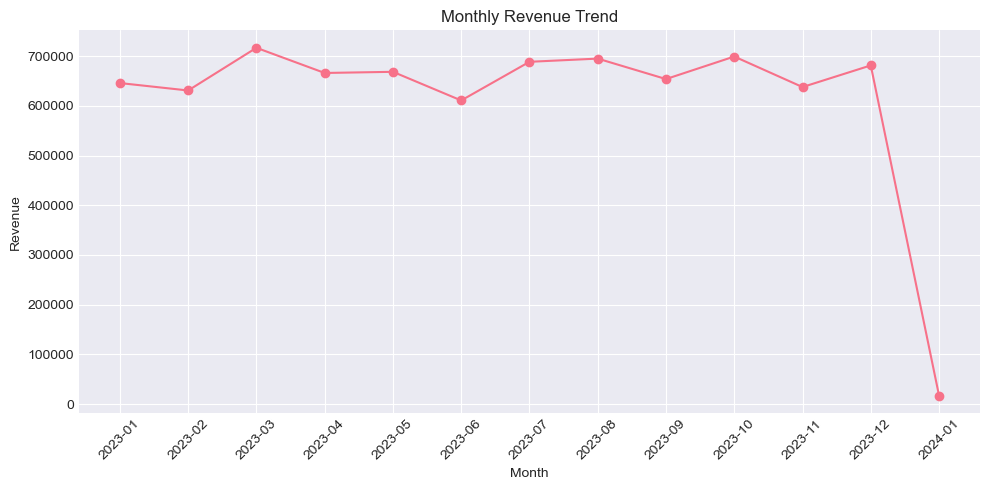

In [57]:
# Monthly Revenue Plot
plt.figure(figsize=(10,5))
plt.plot(
    monthly_data.index.astype(str),
    monthly_data['revenue'],
    marker='o'
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
